# Notebook 3 — Exploratory Data Analysis (EDA)

## What we do
We **look at the data with charts** before building any model.

## Why
- Understand the data (shapes, outliers, relations between variables).
- Spot problems and guess what will be useful for the models.
- Each chart needs a **short interpretation**: write it yourself after running the cell (hints are given).

In [1]:
import os

# The notebooks live in notebooks/, but the data folder is at the project root.
# This moves us to the project root so paths like "data/raw/..." always work.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working folder:", os.getcwd())

Working folder: c:\Users\ycode\Desktop\Projet\Machine Learning\CineMatch AI


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("data/processed/movies_clean.csv", parse_dates=["release_date"])
print(df.shape)
df.head()

(2972, 14)


,movie_id,title,overview,release_date,runtime,original_language,genres,keywords,budget,revenue,popularity,vote_average,vote_count,release_year
0,969681,Spider-Man: Brand New Day,Fighting crime full-time as Spider-Man in a wo...,2026-07-29,145.0,en,Science Fiction|Action|Adventure,mind control|new york city|hero|mutation|secre...,225000000.0,2.505477e+09,623.3942,7.900,3022,2026
1,1599191,Renegade Immortal: Battle of the Immortal Slayer,Trapped in a fatal pursuit within the Celestia...,2026-10-01,NaN,zh,Animation|Action|Adventure|Fantasy,based on fairy tale|xianxia|based on tv series...,NaN,NaN,432.5374,7.800,12,2026
2,1423191,Resident Evil,Medical courier Bryan unwittingly finds himsel...,2026-09-16,95.0,en,Horror|Science Fiction|Adventure,outbreak|survival|decapitation|zombie|based on...,75000000.0,2.454000e+08,364.5221,7.299,750,2026
3,1368337,The Odyssey,"Odysseus, the legendary King of Ithaca, embark...",2026-07-15,173.0,en,Adventure|Action|Fantasy,ship|trojan war|greek mythology|historical fic...,250000000.0,1.767464e+09,322.0423,8.012,4016,2026
4,1228834,The Fix,Disillusioned by the end of the war in Afghani...,2026-09-10,142.0,en,Action|Thriller,central intelligence agency (cia)|war veteran|...,32000000.0,NaN,319.3784,7.100,46,2026


In [3]:
df.describe()

,movie_id,release_date,runtime,budget,revenue,popularity,vote_average,vote_count,release_year
count,2.972000e+03,2972,2949.000000,2.384000e+03,2.436000e+03,2972.000000,2948.000000,2972.000000,2972.000000
mean,4.033889e+05,2010-04-20 01:12:40.699865,110.852153,5.625445e+07,1.866026e+08,18.711951,6.802621,4196.600606,2009.760431
min,1.100000e+01,1931-02-12 00:00:00,6.000000,2.000000e+00,7.000000e+00,5.645100,1.000000,0.000000,1931.000000
25%,9.720000e+03,2002-08-24 18:00:00,96.000000,1.500000e+07,3.286484e+07,10.339025,6.300000,1099.750000,2002.000000
50%,1.486560e+05,2013-11-29 00:00:00,108.000000,3.500000e+07,9.970000e+07,12.854600,6.821000,2650.500000,2013.000000
75%,6.765878e+05,2022-11-11 00:00:00,123.000000,8.000000e+07,2.210671e+08,18.606825,7.390250,5290.000000,2022.000000
max,1.777808e+06,2026-10-03 00:00:00,254.000000,6.588000e+08,2.925500e+09,623.394200,10.000000,41375.000000,2026.000000
std,4.926440e+05,NaN,23.681153,6.050917e+07,2.699314e+08,25.352046,0.847500,4997.775129,15.575177


## 1. Distribution of the ratings (`vote_average`)

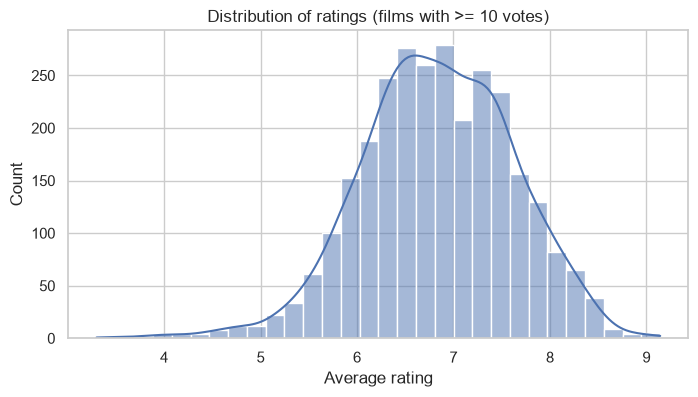

In [4]:
# We keep films with at least 10 votes: a rating based on 1 vote is not reliable
rated = df[df["vote_count"] >= 10]

plt.figure(figsize=(8, 4))
sns.histplot(rated["vote_average"], bins=30, kde=True)
plt.title("Distribution of ratings (films with >= 10 votes)")
plt.xlabel("Average rating")
plt.show()

**Hints**: Where is the peak? Are there many very low or very high ratings? Is the shape symmetric?

**Your interpretation**: ...

## 2. Distribution of the popularity

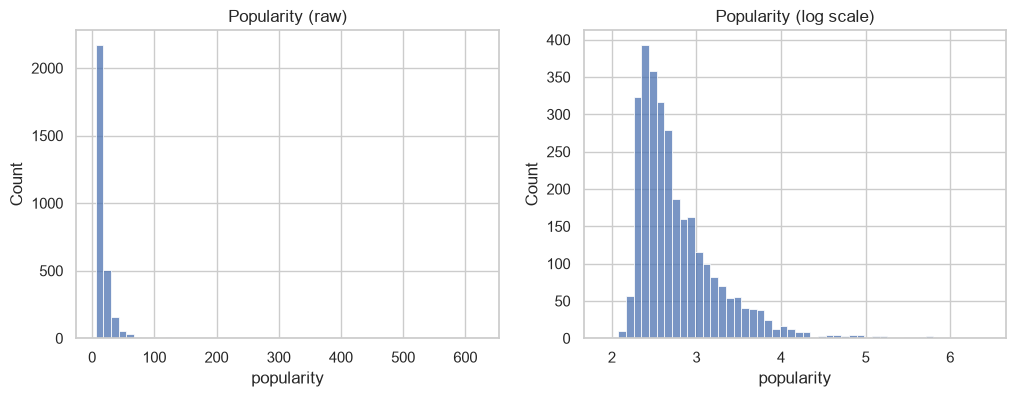

In [5]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["popularity"], bins=50)
plt.title("Popularity (raw)")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df["popularity"]), bins=50)     # log1p = log(1 + x)
plt.title("Popularity (log scale)")

plt.show()

**Hints**: The raw distribution is very stretched to the right (a few films are extremely popular). The **log** compresses big values so we can see the shape. This is why we often use `log` on such variables.

**Your interpretation**: ...

## 3. Number of films per genre

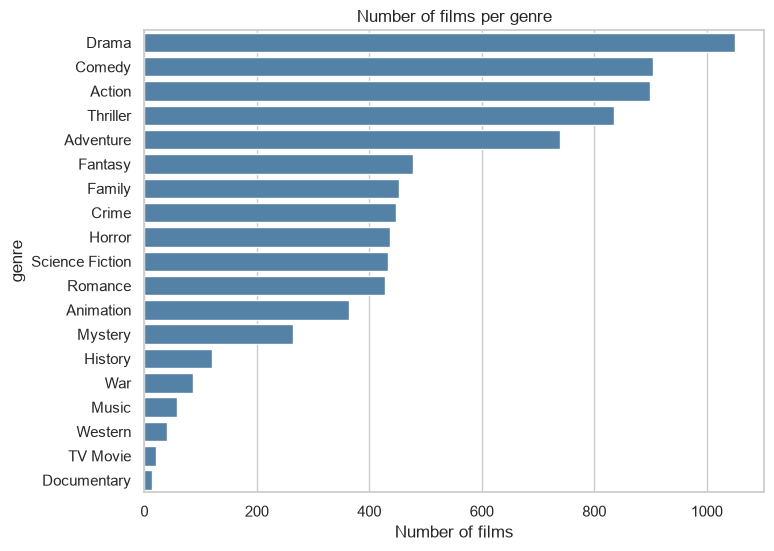

In [6]:
# A film has several genres: we split the "Action|Comedy" text and make one row per genre
genres_table = df.copy()
genres_table["genre"] = genres_table["genres"].fillna("").str.split("|")
genres_table = genres_table.explode("genre")
genres_table = genres_table[genres_table["genre"] != ""]

genre_counts = genres_table["genre"].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, color="steelblue")
plt.title("Number of films per genre")
plt.xlabel("Number of films")
plt.show()

**Hints**: Which genres are the most frequent? Is the dataset balanced between genres?

**Your interpretation**: ...

## 4. Releases per year

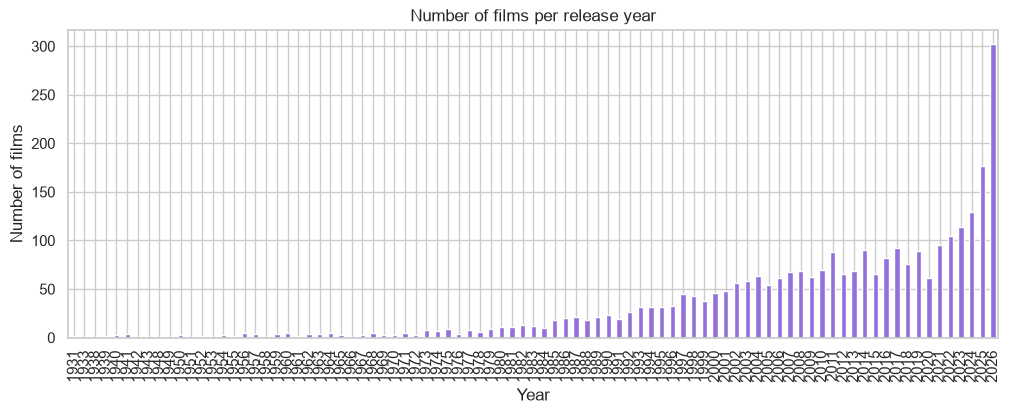

In [7]:
films_per_year = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
films_per_year.plot(kind="bar", color="mediumpurple")
plt.title("Number of films per release year")
plt.xlabel("Year")
plt.ylabel("Number of films")
plt.show()

**Hints**: Which years have the most films? Careful: this reflects **our sample** (the way we downloaded the films), not necessarily the real film industry.

**Your interpretation**: ...

## 5. Runtime (duration)

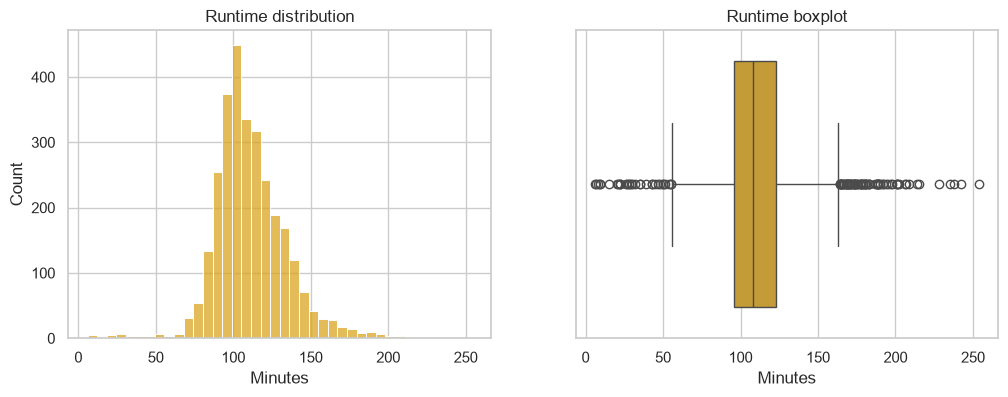

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["runtime"].dropna(), bins=40, color="goldenrod")
plt.title("Runtime distribution")
plt.xlabel("Minutes")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["runtime"], color="goldenrod")
plt.title("Runtime boxplot")
plt.xlabel("Minutes")

plt.show()

**How to read a boxplot**: the box = the middle 50% of the values, the line inside = the median, the dots = **outliers** (unusual values).

**Your interpretation**: ...

## 6. Budget vs revenue

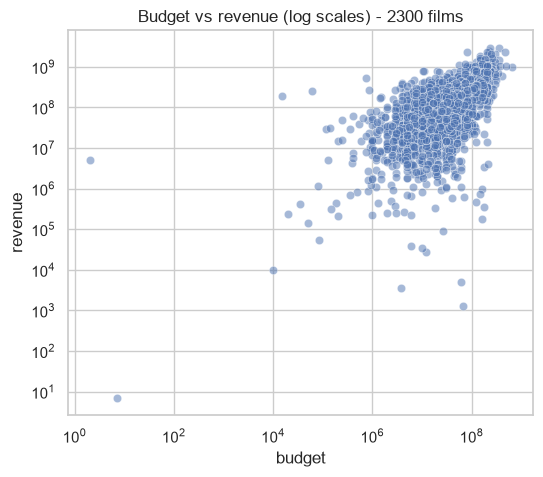

In [9]:
# Only the films where both budget and revenue are known
known = df.dropna(subset=["budget", "revenue"])

plt.figure(figsize=(6, 5))
sns.scatterplot(data=known, x="budget", y="revenue", alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.title("Budget vs revenue (log scales) - " + str(len(known)) + " films")
plt.show()

**Hints**: Is there a positive relation (bigger budget → bigger revenue)? How many films do we lose because budget/revenue are unknown?

**Your interpretation**: ...

## 7. Votes vs popularity

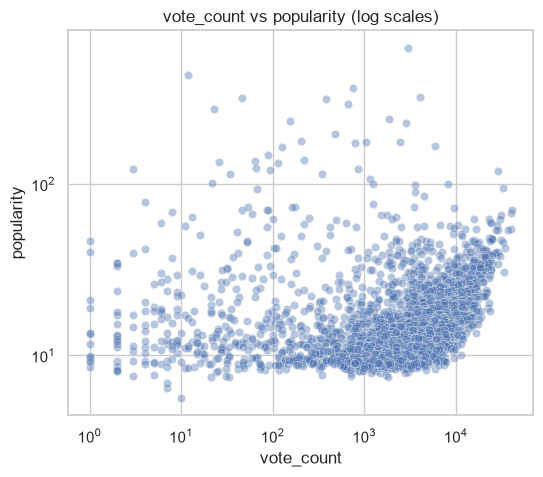

In [10]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="vote_count", y="popularity", alpha=0.4)
plt.xscale("log")
plt.yscale("log")
plt.title("vote_count vs popularity (log scales)")
plt.show()

**Hints**: These two variables move together. **Important for later**: in the classification we will create the target from `vote_count`, so `popularity` is too close to it to be used as a feature (data leakage).

**Your interpretation**: ...

## 8. Boxplots by group

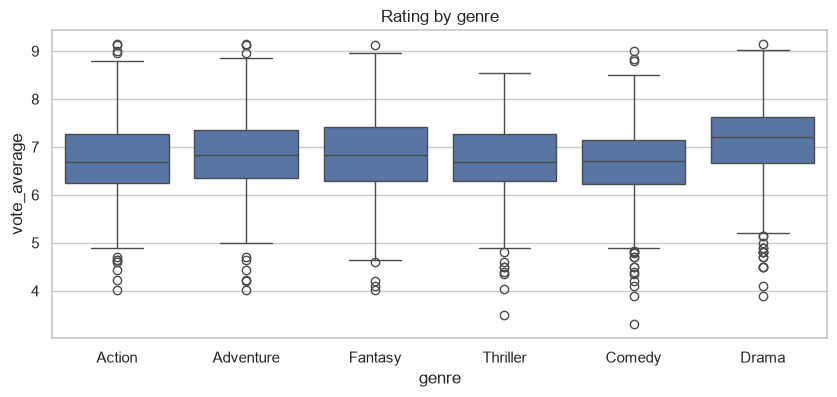

In [11]:
# Rating by genre (6 most frequent genres, films with >= 10 votes)
top_genres = genre_counts.head(6).index
subset = genres_table[genres_table["genre"].isin(top_genres) & (genres_table["vote_count"] >= 10)]

plt.figure(figsize=(10, 4))
sns.boxplot(data=subset, x="genre", y="vote_average")
plt.title("Rating by genre")
plt.show()

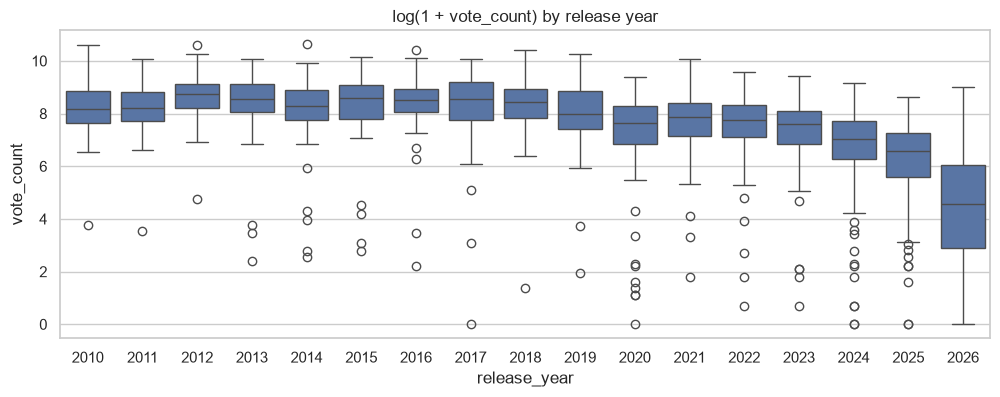

In [12]:
# Number of votes (log) by release year since 2010
recent = df[df["release_year"] >= 2010]

plt.figure(figsize=(12, 4))
sns.boxplot(x=recent["release_year"], y=np.log1p(recent["vote_count"]))
plt.title("log(1 + vote_count) by release year")
plt.show()

**Hints**: Which genre has the best median rating? Do recent films have fewer votes (less time to collect votes)?

**Your interpretation**: ...

## 9. Correlations

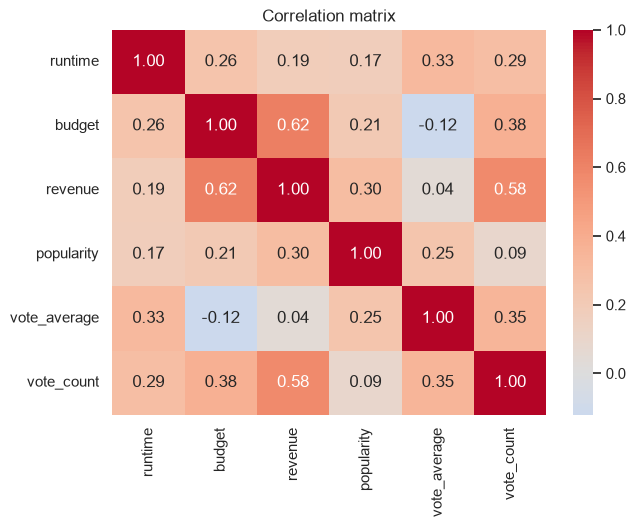

In [13]:
numbers = df[["runtime", "budget", "revenue", "popularity", "vote_average", "vote_count"]].copy()

# log on the stretched variables so extreme values do not dominate
for column in ["budget", "revenue", "popularity", "vote_count"]:
    numbers[column] = np.log1p(numbers[column])

plt.figure(figsize=(7, 5))
sns.heatmap(numbers.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

**How to read it**: a value near +1 = the two variables increase together; near -1 = one increases when the other decreases; near 0 = no linear relation.

**Hints**: Which variables are the most correlated with `vote_count`? (They will be risky as features.)

**Your interpretation**: ...

## What to remember (for the oral)
- Popularity and votes are very stretched → **log** transformation.
- Budget and revenue are missing for many films.
- `popularity` and `vote_count` are strongly related → watch out for **data leakage** in the classification.
- A chart without an interpretation is not useful: always say *what we see* and *why it matters for the models*.